# Lesson 15 activity: data wrangling

## Learning objectives

This activity will help you to:

1. Merge and aggregate data from multiple sources
2. Apply groupby operations to summarize data
3. Calculate meaningful statistics from aggregated data
4. Visualize aggregated results

## Setup

Import the required libraries.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: Merge Data and Calculate Monthly Sales

**Tasks**:

1. Merge `df_sales` and `df_dates` on the `transaction_id` column. Store the result in a dataframe called `df_transactions`.

2. Extract the month from the `sale_date` column and add it as a new column called `month` in `df_transactions`.

3. Calculate the total sales per month using groupby and sum. Store the result in a dataframe called `monthly_sales`.

4. Create a bar chart showing the total sales for each month. Include appropriate labels and title.

**Hints**:

- To merge two dataframes, use `pd.merge()` or the `.merge()` method. You can specify the column to join on with the `on` parameter.
  - Example: `df_merged = pd.merge(df1, df2, on='key_column')`
  - Or: `df_merged = df1.merge(df2, on='key_column')`

- To extract the month from a datetime column, use the `.dt.month` accessor.
  - Example: `df['month'] = df['date_column'].dt.month`

- To group by a column and calculate the sum, use `.groupby()` followed by `.sum()`.
  - Example: `grouped_df = df.groupby('group_column')['value_column'].sum()`
  - You can also use `.reset_index()` to convert the result back to a regular dataframe.

In [14]:
df_sales = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/main/data/sale_amounts.csv')
df_dates = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/main/data/sales_by_date.csv')

In [15]:
# Your code here
print(df_sales.head())
print(df_dates.head())
print("sales cols:", df_sales.columns.tolist())
print("dates cols:", df_dates.columns.tolist())

  transaction_id  sale_amount
0        TXN0001       193.52
1        TXN0002       475.85
2        TXN0003       368.68
3        TXN0004       303.34
4        TXN0005        86.45
  transaction_id   sale_date
0        TXN0001  2024-08-01
1        TXN0002  2024-09-07
2        TXN0003  2024-08-25
3        TXN0004  2024-08-10
4        TXN0005  2024-02-15
sales cols: ['transaction_id', 'sale_amount']
dates cols: ['transaction_id', 'sale_date']


    month  sale_amount
0       1      9033.76
1       2      6506.98
2       3      6878.95
3       4      7782.94
4       5      8599.65
5       6      7684.82
6       7      7094.02
7       8      6660.79
8       9      6694.63
9      10      8267.92
10     11      7055.95
11     12      7794.20


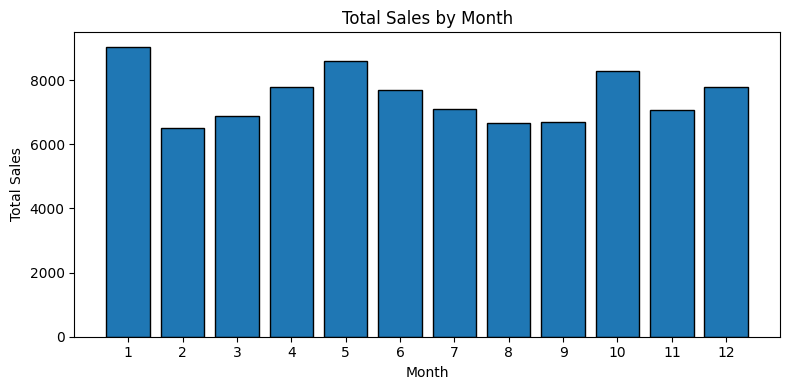

In [16]:
# 1. Merge the two tables on their shared key, one row per transaction
df_transactions = pd.merge(df_sales, df_dates, on='transaction_id')

# 2. Convert sale_date from text to a real datetime, then pull out the month
df_transactions['sale_date'] = pd.to_datetime(df_transactions['sale_date'])
df_transactions['month'] = df_transactions['sale_date'].dt.month

# 3. Total sales per month  (change 'sale_amount' if the column is named differently)
monthly_sales = (
    df_transactions
    .groupby('month')['sale_amount']
    .sum()
    .reset_index()
)
print(monthly_sales)

# 4. Bar chart of total sales by month
plt.figure(figsize=(8, 4))
plt.bar(monthly_sales['month'], monthly_sales['sale_amount'], edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total Sales by Month')
plt.xticks(monthly_sales['month'])   # show every month number on the axis
plt.tight_layout()
plt.show()

## Exercise 2: Analyze Missing Data Patterns

Load the California Housing dataset with missing values and investigate whether the pattern of missing data in the `HouseAge` feature is related to the `Population` feature.

**Background**: 
Sometimes data is not missing completely at random. In real-world scenarios, certain values might be more likely to be missing based on other features in the dataset. This is called Missing Not At Random (MNAR). Understanding these patterns is important for choosing appropriate imputation strategies.

**Tasks**:

1. Load the dataset from `salted_housing_data.csv` and examine the first few rows.

2. Create a new boolean column called `HouseAge_Missing` that indicates whether `HouseAge` is missing (True) or not (False).

3. Use `pd.qcut()` to bin the `Population` feature into 4 quartiles. Store the result in a new column called `Population_Quartile`. Use labels like `['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']`.

4. Calculate the percentage of missing `HouseAge` values for each population quartile. Use `groupby()` to group by `Population_Quartile` and calculate:
   - The count of missing values (sum of `HouseAge_Missing`)
   - The total count in each quartile
   - The percentage missing

5. Create a bar chart showing the percentage of missing `HouseAge` values by population quartile. Add value labels on top of each bar.

6. Based on your analysis, answer: Is `HouseAge` more likely to be missing in certain population groups? What does this suggest about the missing data mechanism?

**Hints**:

- To check for missing values, use `.isnull()` or `.isna()`.
  - Example: `df['HouseAge_Missing'] = df['HouseAge'].isnull()`

- To create quartile bins, use `pd.qcut()` with `q=4`.
  - Example: `df['quartile'] = pd.qcut(df['column'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])`

- To calculate percentage missing by group:
  - Group by the quartile column
  - Use `.agg()` with multiple functions: `{'HouseAge_Missing': ['sum', 'count']}`
  - Calculate percentage: `(sum / count) * 100`

- Missing data mechanisms:
  - **MCAR** (Missing Completely At Random): No relationship between missingness and any variable
  - **MAR** (Missing At Random): Missingness depends on observed variables
  - **MNAR** (Missing Not At Random): Missingness depends on the missing value itself or unobserved variables

In [17]:
housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/main/data/salted_housing_data.csv')

In [18]:
# Your code here
# 1. Look at the data first
print(housing_df.head())
print("HouseAge missing values:", housing_df['HouseAge'].isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810         NaN  2.555556     37.88   
1  8.3014      21.0       NaN   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260       NaN   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
HouseAge missing values: 783


In [19]:
# 2. Boolean flag: True where HouseAge is missing
housing_df['HouseAge_Missing'] = housing_df['HouseAge'].isnull()

# 3. Cut Population into 4 equal-sized quartiles
housing_df['Population_Quartile'] = pd.qcut(
    housing_df['Population'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

# 4. Percent of HouseAge missing within each population quartile
summary = housing_df.groupby('Population_Quartile', observed=True)['HouseAge_Missing'].agg(
    missing_count='sum',     # True counts as 1, so sum = number missing
    total_count='count'      # total rows in the quartile
)
summary['pct_missing'] = summary['missing_count'] / summary['total_count'] * 100
print(summary)


                     missing_count  total_count  pct_missing
Population_Quartile                                         
Q1 (Lowest)                    217         4915     4.415056
Q2                             191         4914     3.886854
Q3                             153         4909     3.116724
Q4 (Highest)                   179         4911     3.644879


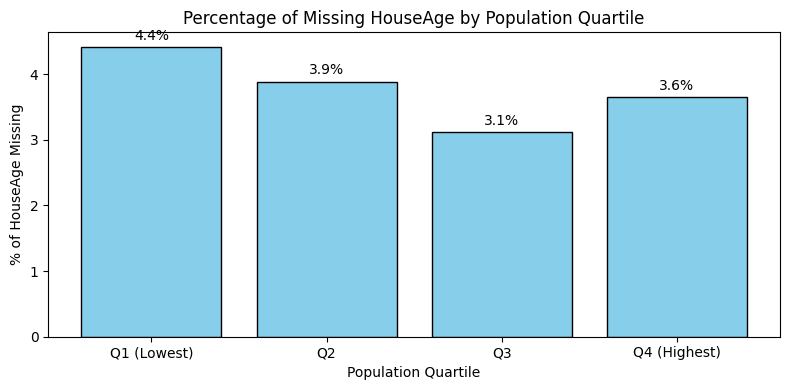

In [20]:
# 5. Bar chart with value labels on top of each bar
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary.index.astype(str), summary['pct_missing'],
              color='skyblue', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('Population Quartile')
ax.set_ylabel('% of HouseAge Missing')
ax.set_title('Percentage of Missing HouseAge by Population Quartile')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import chi2_contingency
import numpy as np

# 6. Chi-square test: is missingness related to population quartile?
contingency = pd.crosstab(housing_df['Population_Quartile'], housing_df['HouseAge_Missing'])
chi2, p, dof, expected = chi2_contingency(contingency)
print("Contingency table (quartile x missing):")
print(contingency)
print(f"\nchi2 = {chi2:.2f},  p-value = {p:.3e},  dof = {dof}")

# Effect size: Cramer's V (strength of the association, 0 to 1)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramer's V = {cramers_v:.3f}")

Contingency table (quartile x missing):
HouseAge_Missing     False  True 
Population_Quartile              
Q1 (Lowest)           4698    217
Q2                    4723    191
Q3                    4756    153
Q4 (Highest)          4732    179

chi2 = 11.82,  p-value = 8.027e-03,  dof = 3
Cramer's V = 0.025


## Exercise 3: Apply Imputation to Missing Data

Now that you've analyzed the missing data pattern, select and apply an appropriate imputation method to fill in the missing `HouseAge` values.

**Background**:
Based on your findings from Exercise 2, you discovered that `HouseAge` is more likely to be missing in areas with lower population (MNAR pattern). This information should guide your choice of imputation method. Advanced methods like KNN or Iterative Imputation can leverage relationships between features, which is particularly useful when data is not missing completely at random.

**Tasks**:

1. Choose an imputation method. Consider:
   - Simple methods: Mean or Median imputation
   - Advanced methods: KNN Imputation or Iterative Imputation
   - Justify your choice based on the missing data pattern you discovered
2. Apply your chosen imputation method to fill the missing `HouseAge` values. Store the result in a new column called `HouseAge_imputed`.

3. Compare the distribution of the original `HouseAge` (non-missing values only) with the imputed values:
   - Create a histogram showing both distributions
   - Calculate summary statistics (mean, median, std) for both

4. Evaluate your imputation:
   - Does the imputed distribution look reasonable compared to the original?
   - Are there any obvious problems or artifacts introduced by the imputation?
   - Would a different method have been better? Why or why not?

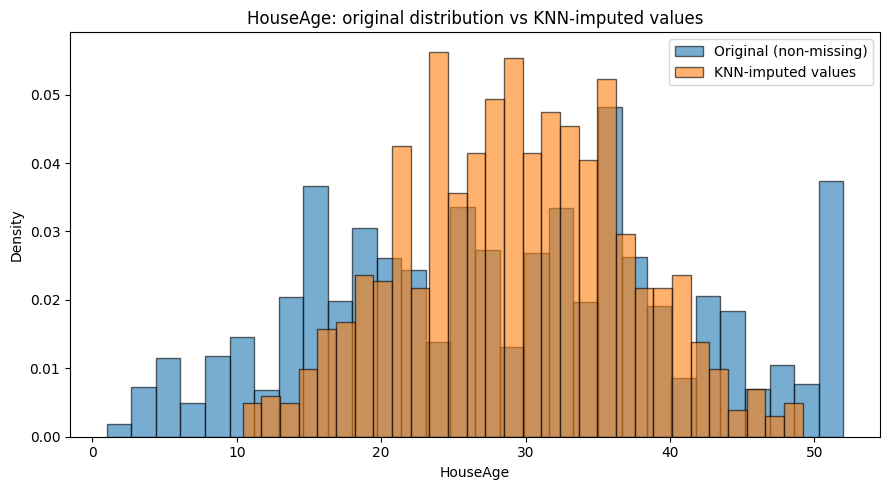

Original non-missing:  mean=28.61  median=29.00  std=12.58  n=19857
KNN-imputed values:    mean=29.34  median=29.20  std=7.63  n=783


In [22]:
# Your code here
from sklearn.impute import KNNImputer

# 1. Method: KNN imputation.
#    Justification: Exercise 2 showed HouseAge missingness depends on Population
#    (chi-square p = 0.008), so the data is not MCAR. A method that uses the other
#    features to fill the holes (KNN) is justified over a blind mean or median.

# 2. Apply KNN. Use only the original numeric columns, not the helper columns
#    we added (HouseAge_Missing leaks the target; Population_Quartile is categorical).
numeric_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

knn = KNNImputer(n_neighbors=5)
imputed_array = knn.fit_transform(housing_df[numeric_cols])

# Put the imputed HouseAge back as a new column
houseage_idx = numeric_cols.index('HouseAge')
housing_df['HouseAge_imputed'] = imputed_array[:, houseage_idx]

# 3. Compare the original (non-missing) values with the values KNN filled in.
#    density=True normalizes both so their shapes compare fairly despite different counts.
original = housing_df.loc[~housing_df['HouseAge_Missing'], 'HouseAge']
filled   = housing_df.loc[housing_df['HouseAge_Missing'], 'HouseAge_imputed']

plt.figure(figsize=(9, 5))
plt.hist(original, bins=30, density=True, alpha=0.6,
         label='Original (non-missing)', edgecolor='black')
plt.hist(filled, bins=30, density=True, alpha=0.6,
         label='KNN-imputed values', edgecolor='black')
plt.xlabel('HouseAge')
plt.ylabel('Density')
plt.title('HouseAge: original distribution vs KNN-imputed values')
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics for both
print(f"Original non-missing:  mean={original.mean():.2f}  median={original.median():.2f}  std={original.std():.2f}  n={len(original)}")
print(f"KNN-imputed values:    mean={filled.mean():.2f}  median={filled.median():.2f}  std={filled.std():.2f}  n={len(filled)}")

In [23]:
from scipy.stats import ks_2samp
D, p = ks_2samp(original, filled)
print(f"KS statistic D = {D:.3f},  p-value = {p:.3e}")

KS statistic D = 0.188,  p-value = 8.377e-24
